In [1]:
source('../utilities/functions/gex-violins-colors.R')
library(patchwork)

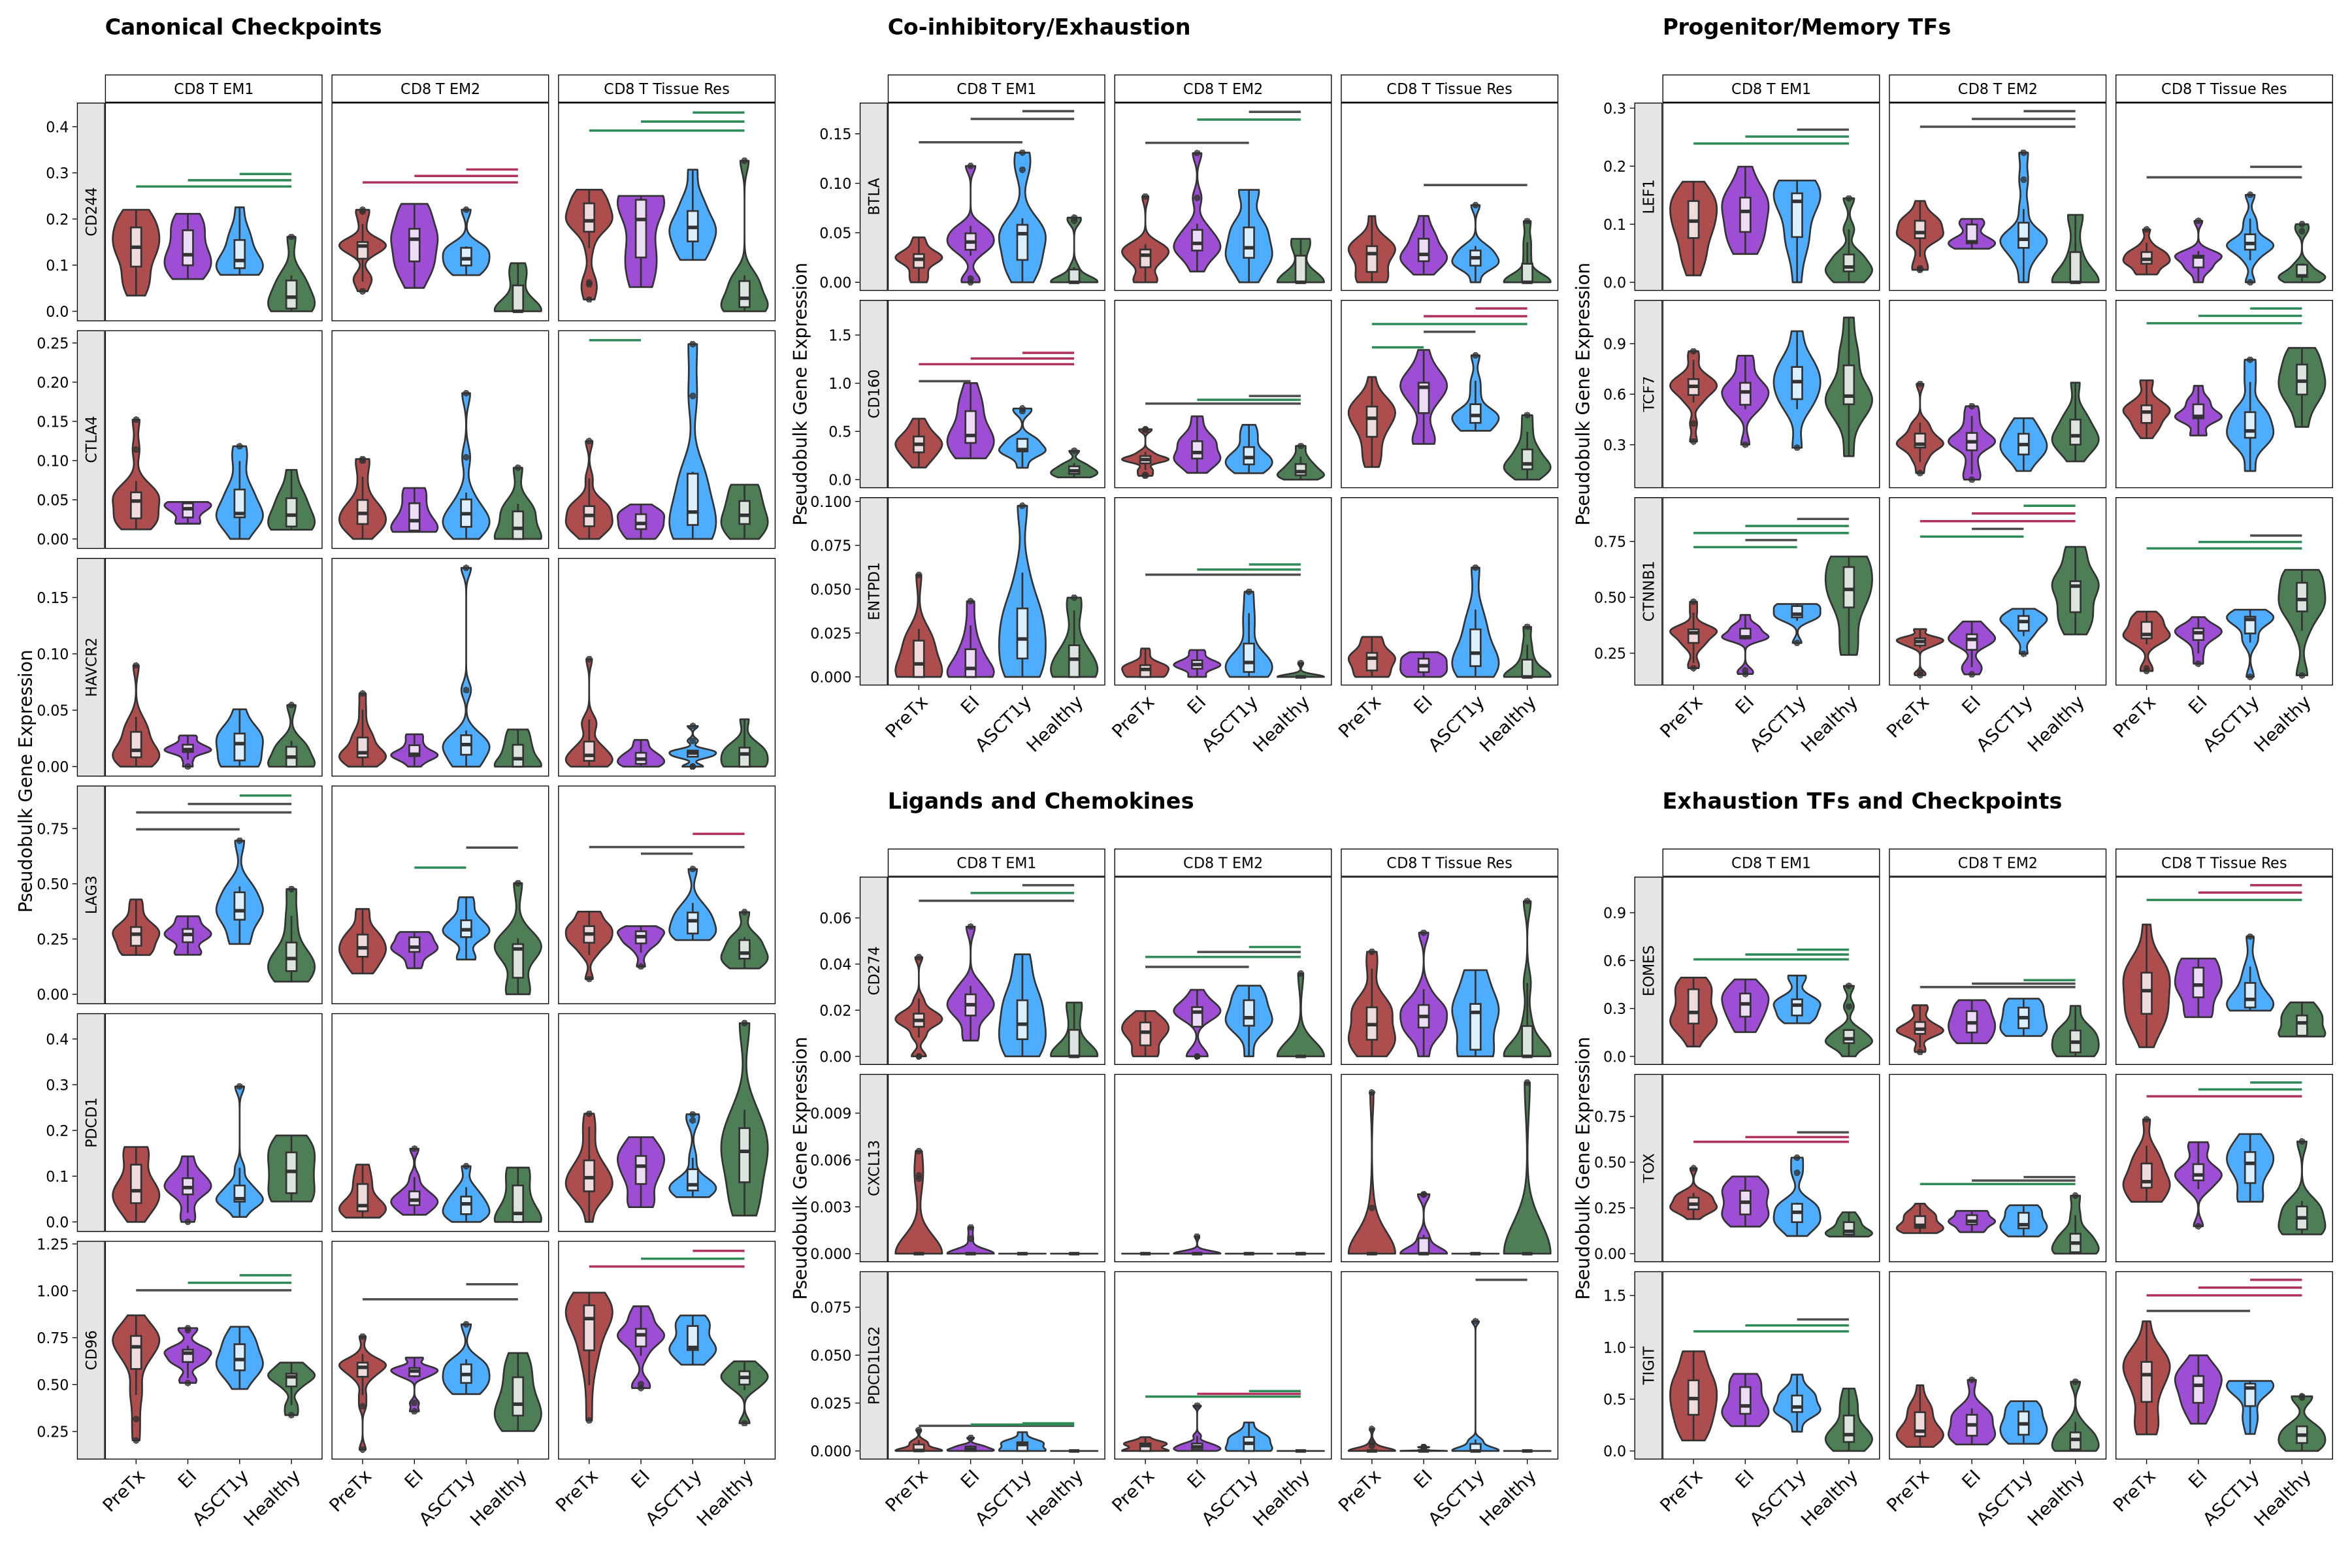

In [2]:
# Common parameters
common_params <- list(
  metadata_path = '../../data/figure-inputs/metadata/bmmc_sample_kit_metadata.csv',
  files_dir = '../../data/figure-inputs/bmmc_l3_lognorm_gexp_celltypes_per_samplekit',
  celltypes = c('CD8 T EM1', 'CD8 T EM2', 'CD8 T Tissue Res'),
  visits = c('PreTx', 'EI', 'ASCT1y', 'Healthy'),
  paired_visits = c('PreTx', 'EI', 'ASCT1y'),
  unpaired_visit = 'Healthy',
  subtitle = '',
  plot_width = 6,
  plot_height = 12,
  base_size = 10,
  step.increase = 0.06,
  show_pval_legend = FALSE,
  ylabs = 'Pseudobulk Gene Expression',
  pval_colors = c('maroon', 'seagreen', 'gray30', 'gray50'),
  line_size = 0.6
)

p1 <- do.call(plot_expression_violins, c(
  list(gene_list = c("CD244", "CTLA4", "HAVCR2", "LAG3", "PDCD1", "CD96"),
       title = "Canonical Checkpoints"),
  common_params
))

p2 <- do.call(plot_expression_violins, c(
  list(gene_list = c("BTLA", "CD160", "ENTPD1"),
       title = "Co-inhibitory/Exhaustion",
       plot_height = 6),
  common_params[!names(common_params) %in% "plot_height"]
))

p3 <- do.call(plot_expression_violins, c(
  list(gene_list = c("CD274", "CXCL13", "PDCD1LG2"),
       title = "Ligands and Chemokines",
       plot_height = 6),
  common_params[!names(common_params) %in% "plot_height"]
))

p4 <- do.call(plot_expression_violins, c(
  list(gene_list = c("LEF1", "TCF7", "CTNNB1"),
       title = "Progenitor/Memory TFs",
       plot_height = 6),
  common_params[!names(common_params) %in% "plot_height"]
))

p5 <- do.call(plot_expression_violins, c(
  list(gene_list = c("EOMES", "TOX", "TIGIT"),
       title = "Exhaustion TFs and Checkpoints",
       plot_height = 6),
  common_params[!names(common_params) %in% "plot_height"]
))

options(repr.plot.width = 18, repr.plot.height = 12)

# Arrange with p1 double height
combined_plot <- p1 + (p2 / p3) + (p4 / p5) + plot_layout(widths = c(1, 1, 1))
combined_plot

ggsave("../../data/figure-outputs/supplementary-6/sup_6a.pdf", plot = combined_plot, width = 18, height = 12, dpi = 200, device = cairo_pdf)